In [3]:
import os

os.listdir("/content")

['.config',
 'yellow_tripdata_2026-01.parquet',
 'taxi_zone_lookup.csv',
 'sample_data']

In [4]:
!pip install duckdb -q

In [5]:
import duckdb
import pandas as pd

con = duckdb.connect()

In [6]:
query = """
SELECT *
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet')
LIMIT 5;
"""

con.execute(query).df()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1,0.97,1,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0,0.90,1,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0,1.40,1,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4,5.58,1,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0,2.16,1,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [7]:
query = """
SELECT COUNT(*) AS total_trips
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet');
"""

con.execute(query).df()

,total_trips
0,3724889


In [8]:
query = """
SELECT
    COUNT(*) AS total_trips,

    SUM(CASE
        WHEN trip_distance IS NULL THEN 1
        ELSE 0
    END) AS null_distance,

    SUM(CASE
        WHEN trip_distance <= 0 THEN 1
        ELSE 0
    END) AS nonpositive_distance,

    SUM(CASE
        WHEN fare_amount IS NULL THEN 1
        ELSE 0
    END) AS null_fare,

    SUM(CASE
        WHEN fare_amount < 0 THEN 1
        ELSE 0
    END) AS negative_fare,

    SUM(CASE
        WHEN tpep_dropoff_datetime <= tpep_pickup_datetime THEN 1
        ELSE 0
    END) AS invalid_time_order

FROM read_parquet('/content/yellow_tripdata_2026-01.parquet');
"""

con.execute(query).df()

,total_trips,null_distance,nonpositive_distance,null_fare,negative_fare,invalid_time_order
0,3724889,0.0,125738.0,0.0,39463.0,45070.0


In [9]:
query = """
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    trip_distance,
    fare_amount,
    total_amount,
    PULocationID,
    DOLocationID
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet')
WHERE trip_distance <= 0
LIMIT 20;
"""

con.execute(query).df()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID
0,2026-01-01 00:21:36,2026-01-01 00:22:52,0.0,3.0,8.00,239,43
1,2026-01-01 00:11:22,2026-01-01 00:34:04,0.0,18.4,24.15,43,170
2,2026-01-01 00:54:54,2026-01-01 01:09:08,0.0,12.8,23.15,161,137
3,2026-01-01 00:32:10,2026-01-01 00:32:14,0.0,50.0,54.25,162,162
4,2026-01-01 00:45:48,2026-01-01 00:45:54,0.0,50.0,54.25,261,261
5,2026-01-01 00:56:10,2026-01-01 00:56:24,0.0,3.0,8.75,113,114
6,2026-01-01 00:35:40,2026-01-01 00:39:04,0.0,5.1,7.60,41,41
7,2026-01-01 00:11:44,2026-01-01 00:11:48,0.0,40.0,41.00,133,133
8,2026-01-01 00:40:52,2026-01-01 00:40:58,0.0,124.0,130.00,265,265
9,2026-01-01 00:28:16,2026-01-01 00:28:21,0.0,60.0,62.08,265,265


In [10]:
query = """
SELECT
    SUM(CASE
        WHEN trip_distance <= 0
         AND fare_amount < 0
        THEN 1 ELSE 0
    END) AS distance_and_negative_fare,

    SUM(CASE
        WHEN trip_distance <= 0
         AND tpep_dropoff_datetime <= tpep_pickup_datetime
        THEN 1 ELSE 0
    END) AS distance_and_invalid_time,

    SUM(CASE
        WHEN fare_amount < 0
         AND tpep_dropoff_datetime <= tpep_pickup_datetime
        THEN 1 ELSE 0
    END) AS negative_fare_and_invalid_time,

    SUM(CASE
        WHEN trip_distance <= 0
         AND fare_amount < 0
         AND tpep_dropoff_datetime <= tpep_pickup_datetime
        THEN 1 ELSE 0
    END) AS all_three,

    SUM(CASE
        WHEN trip_distance <= 0
          OR fare_amount < 0
          OR tpep_dropoff_datetime <= tpep_pickup_datetime
        THEN 1 ELSE 0
    END) AS any_quality_issue

FROM read_parquet('/content/yellow_tripdata_2026-01.parquet');
"""

con.execute(query).df()

,distance_and_negative_fare,distance_and_invalid_time,negative_fare_and_invalid_time,all_three,any_quality_issue
0,2755.0,1164.0,0.0,0.0,206352.0


In [12]:
query = """
CREATE OR REPLACE VIEW clean_trips AS

SELECT *
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet')

WHERE trip_distance > 0
  AND fare_amount >= 0
  AND tpep_dropoff_datetime > tpep_pickup_datetime;
"""

con.execute(query)

In [13]:
query = """
SELECT
    COUNT(*) AS clean_trips
FROM clean_trips;
"""

con.execute(query).df()

,clean_trips
0,3518537


In [14]:
query = """
SELECT
    SUM(CASE WHEN trip_distance <= 0 THEN 1 ELSE 0 END) AS bad_distance,
    SUM(CASE WHEN fare_amount < 0 THEN 1 ELSE 0 END) AS bad_fare,
    SUM(CASE
        WHEN tpep_dropoff_datetime <= tpep_pickup_datetime
        THEN 1 ELSE 0
    END) AS bad_time
FROM clean_trips;
"""

con.execute(query).df()

,bad_distance,bad_fare,bad_time
0,0.0,0.0,0.0


In [15]:
query = """
SELECT
    COUNT(*) AS total_clean_trips,

    MIN(trip_distance) AS min_distance,
    AVG(trip_distance) AS avg_distance,
    MEDIAN(trip_distance) AS median_distance,
    QUANTILE_CONT(trip_distance, 0.95) AS p95_distance,
    QUANTILE_CONT(trip_distance, 0.99) AS p99_distance,
    MAX(trip_distance) AS max_distance,

    AVG(fare_amount) AS avg_fare,
    MEDIAN(fare_amount) AS median_fare,
    QUANTILE_CONT(fare_amount, 0.99) AS p99_fare,
    MAX(fare_amount) AS max_fare,

    AVG(
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0
    ) AS avg_duration_min,

    MEDIAN(
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0
    ) AS median_duration_min,

    QUANTILE_CONT(
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0,
        0.99
    ) AS p99_duration_min,

    MAX(
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0
    ) AS max_duration_min

FROM clean_trips;
"""

con.execute(query).df()

,total_clean_trips,min_distance,avg_distance,median_distance,p95_distance,p99_distance,max_distance,avg_fare,median_fare,p99_fare,max_fare,avg_duration_min,median_duration_min,p99_duration_min,max_duration_min
0,3518537,0.01,6.756656,1.9,12.7,19.6,269097.48,21.081105,15.6,78.87,2555.2,17.474132,13.516667,72.1,5293.333333


In [16]:
query = """
WITH trip_metrics AS (
    SELECT
        tpep_pickup_datetime,
        tpep_dropoff_datetime,
        trip_distance,
        fare_amount,
        total_amount,
        PULocationID,
        DOLocationID,

        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0 AS duration_min

    FROM clean_trips
)

SELECT
    *,
    trip_distance / (duration_min / 60.0) AS avg_speed_mph

FROM trip_metrics

ORDER BY trip_distance DESC

LIMIT 20;
"""

con.execute(query).df()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,duration_min,avg_speed_mph
0,2026-01-28 01:08:00,2026-01-28 01:16:00,269097.48,12.19,16.94,79,144,8.0,2.018231e+06
1,2026-01-30 13:00:00,2026-01-30 13:38:00,237567.19,72.99,81.95,42,130,38.0,3.751061e+05
2,2026-01-21 16:31:00,2026-01-21 16:40:00,236216.69,13.58,21.33,234,107,9.0,1.574778e+06
3,2026-01-17 10:40:00,2026-01-17 10:57:00,236183.06,22.75,34.96,137,82,17.0,8.335873e+05
4,2026-01-02 21:31:00,2026-01-02 21:55:00,221544.91,31.21,39.55,249,41,24.0,5.538623e+05
5,2026-01-02 07:07:00,2026-01-02 07:18:00,221436.73,27.61,32.36,231,161,11.0,1.207837e+06
6,2026-01-17 10:39:00,2026-01-17 10:56:00,196490.48,33.59,38.34,13,162,17.0,6.934958e+05
7,2026-01-29 07:51:00,2026-01-29 08:26:00,192081.68,60.20,64.95,33,246,35.0,3.292829e+05
8,2026-01-07 17:51:00,2026-01-07 17:56:00,184908.33,12.18,16.93,164,186,5.0,2.218900e+06
9,2026-01-27 14:46:00,2026-01-27 16:10:00,183363.75,71.01,75.76,230,74,84.0,1.309741e+05


In [17]:
query = """
WITH trip_metrics AS (
    SELECT
        trip_distance,
        fare_amount,
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 3600.0 AS duration_hours
    FROM clean_trips
),

speed_metrics AS (
    SELECT
        trip_distance,
        fare_amount,
        duration_hours,
        trip_distance / duration_hours AS avg_speed_mph
    FROM trip_metrics
)

SELECT
    MEDIAN(avg_speed_mph) AS median_speed,
    QUANTILE_CONT(avg_speed_mph, 0.95) AS p95_speed,
    QUANTILE_CONT(avg_speed_mph, 0.99) AS p99_speed,
    QUANTILE_CONT(avg_speed_mph, 0.999) AS p999_speed,
    MAX(avg_speed_mph) AS max_speed,

    SUM(CASE WHEN avg_speed_mph > 80 THEN 1 ELSE 0 END) AS trips_over_80_mph,
    SUM(CASE WHEN avg_speed_mph > 100 THEN 1 ELSE 0 END) AS trips_over_100_mph,
    SUM(CASE WHEN avg_speed_mph > 200 THEN 1 ELSE 0 END) AS trips_over_200_mph,

    SUM(CASE WHEN trip_distance > 100 THEN 1 ELSE 0 END) AS trips_over_100_miles

FROM speed_metrics;
"""

con.execute(query).df()

,median_speed,p95_speed,p99_speed,p999_speed,max_speed,trips_over_80_mph,trips_over_100_mph,trips_over_200_mph,trips_over_100_miles
0,9.43131,25.102906,35.220217,46.813006,2218899.96,860.0,721.0,489.0,155.0


In [18]:
query = """
CREATE OR REPLACE VIEW analysis_trips AS

WITH trip_metrics AS (
    SELECT
        *,
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0 AS duration_min
    FROM clean_trips
)

SELECT
    *,
    trip_distance / (duration_min / 60.0) AS avg_speed_mph

FROM trip_metrics

WHERE duration_min > 0
  AND trip_distance / (duration_min / 60.0) <= 80;
"""

con.execute(query)

In [19]:
query = """
SELECT
    COUNT(*) AS final_analysis_trips,
    MIN(avg_speed_mph) AS min_speed,
    MEDIAN(avg_speed_mph) AS median_speed,
    QUANTILE_CONT(avg_speed_mph, 0.99) AS p99_speed,
    MAX(avg_speed_mph) AS max_speed
FROM analysis_trips;
"""

con.execute(query).df()

,final_analysis_trips,min_speed,median_speed,p99_speed,max_speed
0,3517677,0.000342,9.429892,35.088876,79.857347


In [20]:
query = """
SELECT
    3724889 AS raw_records,
    COUNT(*) AS analysis_records,
    ROUND(
        COUNT(*) * 100.0 / 3724889,
        2
    ) AS retained_pct
FROM analysis_trips;
"""

con.execute(query).df()

,raw_records,analysis_records,retained_pct
0,3724889,3517677,94.44


In [21]:
query = """
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    duration_min,
    trip_distance,
    avg_speed_mph,
    fare_amount,
    total_amount,
    PULocationID,
    DOLocationID
FROM analysis_trips
ORDER BY duration_min DESC
LIMIT 20;
"""

con.execute(query).df()

,tpep_pickup_datetime,tpep_dropoff_datetime,duration_min,trip_distance,avg_speed_mph,fare_amount,total_amount,PULocationID,DOLocationID
0,2026-01-09 20:41:45,2026-01-13 12:55:05,5293.333333,2.90,0.032872,15.60,20.60,236,74
1,2026-01-23 22:38:23,2026-01-27 12:32:58,5154.583333,4.86,0.056571,67.40,71.65,132,130
2,2026-01-21 09:04:19,2026-01-24 08:50:35,4306.266667,21.73,0.302768,82.80,86.05,132,26
3,2026-01-25 00:43:10,2026-01-27 11:28:52,3525.700000,48.65,0.827921,2555.20,2560.20,79,193
4,2026-01-24 09:28:41,2026-01-26 11:51:47,3023.100000,2.10,0.041679,10.00,13.25,132,191
5,2026-01-25 08:03:43,2026-01-27 07:23:10,2839.450000,8.87,0.187431,33.80,37.05,132,93
6,2026-01-16 17:38:32,2026-01-18 14:20:15,2681.716667,2.07,0.046314,17.04,23.96,233,138
7,2026-01-17 10:04:24,2026-01-19 04:34:25,2550.016667,8.05,0.189411,31.00,32.50,265,197
8,2026-01-29 18:34:08,2026-01-31 11:40:31,2466.383333,1.63,0.039653,14.20,21.45,237,231
9,2026-01-02 15:13:47,2026-01-04 06:18:30,2344.716667,16.82,0.430414,70.00,81.69,230,195


In [22]:
query = """
SELECT
    CASE
        WHEN duration_min <= 30 THEN '0-30 min'
        WHEN duration_min <= 60 THEN '31-60 min'
        WHEN duration_min <= 120 THEN '61-120 min'
        WHEN duration_min <= 240 THEN '121-240 min'
        ELSE '240+ min'
    END AS duration_bucket,

    COUNT(*) AS trip_count,

    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS pct_of_trips

FROM analysis_trips

GROUP BY duration_bucket

ORDER BY
    CASE duration_bucket
        WHEN '0-30 min' THEN 1
        WHEN '31-60 min' THEN 2
        WHEN '61-120 min' THEN 3
        WHEN '121-240 min' THEN 4
        ELSE 5
    END;
"""

con.execute(query).df()

,duration_bucket,trip_count,pct_of_trips
0,0-30 min,3094009,87.96
1,31-60 min,356224,10.13
2,61-120 min,63150,1.80
3,121-240 min,2937,0.08
4,240+ min,1357,0.04


In [23]:
query = """
SELECT
    CASE
        WHEN duration_min <= 30 THEN '0-30 min'
        WHEN duration_min <= 60 THEN '31-60 min'
        WHEN duration_min <= 120 THEN '61-120 min'
        WHEN duration_min <= 240 THEN '121-240 min'
        ELSE '240+ min'
    END AS duration_bucket,

    COUNT(*) AS trip_count,

    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS pct_of_trips

FROM analysis_trips

GROUP BY duration_bucket

ORDER BY
    CASE duration_bucket
        WHEN '0-30 min' THEN 1
        WHEN '31-60 min' THEN 2
        WHEN '61-120 min' THEN 3
        WHEN '121-240 min' THEN 4
        ELSE 5
    END;
"""

con.execute(query).df()

,duration_bucket,trip_count,pct_of_trips
0,0-30 min,3094009,87.96
1,31-60 min,356224,10.13
2,61-120 min,63150,1.80
3,121-240 min,2937,0.08
4,240+ min,1357,0.04


In [24]:
query = """
SELECT
    SUM(CASE WHEN total_amount < 0 THEN 1 ELSE 0 END) AS negative_total_amount,

    SUM(CASE WHEN total_amount = 0 THEN 1 ELSE 0 END) AS zero_total_amount,

    MIN(total_amount) AS min_total_amount,
    MEDIAN(total_amount) AS median_total_amount,
    QUANTILE_CONT(total_amount, 0.99) AS p99_total_amount,
    MAX(total_amount) AS max_total_amount

FROM analysis_trips;
"""

con.execute(query).df()

,negative_total_amount,zero_total_amount,min_total_amount,median_total_amount,p99_total_amount,max_total_amount
0,383.0,257.0,-6.5,23.1,104.51,2560.2


In [25]:
query = """
SELECT
    SUM(CASE WHEN total_amount < 0 THEN 1 ELSE 0 END) AS negative_total_amount,

    SUM(CASE WHEN total_amount = 0 THEN 1 ELSE 0 END) AS zero_total_amount,

    MIN(total_amount) AS min_total_amount,
    MEDIAN(total_amount) AS median_total_amount,
    QUANTILE_CONT(total_amount, 0.95) AS p95_total_amount,
    QUANTILE_CONT(total_amount, 0.99) AS p99_total_amount,
    MAX(total_amount) AS max_total_amount

FROM analysis_trips;
"""

con.execute(query).df()

,negative_total_amount,zero_total_amount,min_total_amount,median_total_amount,p95_total_amount,p99_total_amount,max_total_amount
0,383.0,257.0,-6.5,23.1,75.19,104.51,2560.2


In [26]:
query = """
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    duration_min,
    trip_distance,
    avg_speed_mph,
    fare_amount,
    tip_amount,
    tolls_amount,
    total_amount,
    PULocationID,
    DOLocationID
FROM analysis_trips
ORDER BY total_amount DESC
LIMIT 20;
"""

con.execute(query).df()

,tpep_pickup_datetime,tpep_dropoff_datetime,duration_min,trip_distance,avg_speed_mph,fare_amount,tip_amount,tolls_amount,total_amount,PULocationID,DOLocationID
0,2026-01-25 00:43:10,2026-01-27 11:28:52,3525.700000,48.65,0.827921,2555.2,0.0,0.00,2560.20,79,193
1,2026-01-26 17:27:28,2026-01-26 20:22:44,175.266667,128.05,43.836059,899.0,0.0,7.46,911.71,132,265
2,2026-01-24 00:18:59,2026-01-24 00:43:52,24.883333,9.03,21.773610,900.0,0.0,0.00,904.25,147,146
3,2026-01-26 13:30:11,2026-01-26 16:04:09,153.966667,138.54,53.988309,893.4,0.0,7.46,904.11,132,265
4,2026-01-22 10:21:55,2026-01-22 12:35:48,133.883333,121.18,54.306984,837.4,0.0,0.00,838.90,250,265
5,2026-01-19 13:10:40,2026-01-19 15:07:45,117.083333,116.46,59.680569,826.2,0.0,0.00,827.70,265,265
6,2026-01-29 20:16:15,2026-01-30 14:57:24,1121.150000,13.92,0.744949,800.3,0.0,0.00,807.55,233,193
7,2026-01-04 16:13:36,2026-01-04 18:27:44,134.133333,123.18,55.100398,797.5,0.0,6.94,807.19,132,265
8,2026-01-09 13:54:47,2026-01-09 13:54:55,0.133333,0.03,13.500000,800.0,0.0,0.00,801.00,76,63
9,2026-01-31 14:22:29,2026-01-31 15:01:33,39.066667,1.50,2.303754,31.7,766.0,0.00,799.20,78,248


In [27]:
query = """
SELECT
    tpep_pickup_datetime,
    tpep_dropoff_datetime,
    trip_distance,
    fare_amount,
    extra,
    mta_tax,
    tip_amount,
    tolls_amount,
    improvement_surcharge,
    total_amount,
    payment_type,
    PULocationID,
    DOLocationID
FROM analysis_trips
WHERE total_amount < 0
LIMIT 20;
"""

con.execute(query).df()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,payment_type,PULocationID,DOLocationID
0,2026-01-01 00:39:56,2026-01-01 00:46:51,0.48,0.0,0.0,0.0,0.0,0.0,0.0,-3.25,2,113,113
1,2026-01-01 00:30:40,2026-01-01 01:36:27,6.16,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.75,2,232,234
2,2026-01-01 01:04:05,2026-01-01 01:17:13,1.40,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,2,75,75
3,2026-01-01 01:45:42,2026-01-01 02:22:47,9.50,0.0,0.0,0.0,0.0,0.0,0.0,-3.25,2,237,232
4,2026-01-01 01:58:39,2026-01-01 02:03:36,0.18,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.75,2,79,79
5,2026-01-01 01:10:02,2026-01-01 01:32:16,4.75,0.0,0.0,0.0,0.0,0.0,0.0,-3.25,2,233,148
6,2026-01-01 01:16:07,2026-01-01 01:17:53,0.48,0.0,0.0,0.0,0.0,0.0,0.0,-3.25,2,170,170
7,2026-01-01 01:15:39,2026-01-01 01:17:01,0.02,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.75,2,79,79
8,2026-01-01 01:53:08,2026-01-01 01:54:19,0.63,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,2,49,49
9,2026-01-01 02:53:49,2026-01-01 02:54:05,0.01,0.0,0.0,0.0,0.0,0.0,0.0,-3.25,2,232,232


In [30]:
query = """
CREATE OR REPLACE VIEW final_trips AS

SELECT *
FROM analysis_trips

WHERE total_amount >= 0
  AND duration_min <= 240;
"""

con.execute(query)

In [31]:
query = """
SELECT
    COUNT(*) AS final_trip_count,
    MIN(trip_distance) AS min_distance,
    MIN(fare_amount) AS min_fare,
    MIN(total_amount) AS min_total_amount,
    MAX(duration_min) AS max_duration_min,
    MAX(avg_speed_mph) AS max_speed_mph
FROM final_trips;
"""

con.execute(query).df()

,final_trip_count,min_distance,min_fare,min_total_amount,max_duration_min,max_speed_mph
0,3515940,0.01,0.0,0.0,238.983333,79.857347


In [32]:
query = """
SELECT
    EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS trip_count
FROM final_trips
GROUP BY pickup_hour
ORDER BY pickup_hour;
"""

hourly_demand = con.execute(query).df()

hourly_demand

,pickup_hour,trip_count
0,0,108390
1,1,75206
2,2,52163
3,3,37252
4,4,27536
5,5,31707
6,6,61693
7,7,110059
8,8,143671
9,9,151664


In [33]:
query = """
SELECT
    EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS trip_count
FROM final_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 5;
"""

con.execute(query).df()

,pickup_hour,trip_count
0,18,229572
1,17,221027
2,15,213453
3,19,208881
4,20,206342


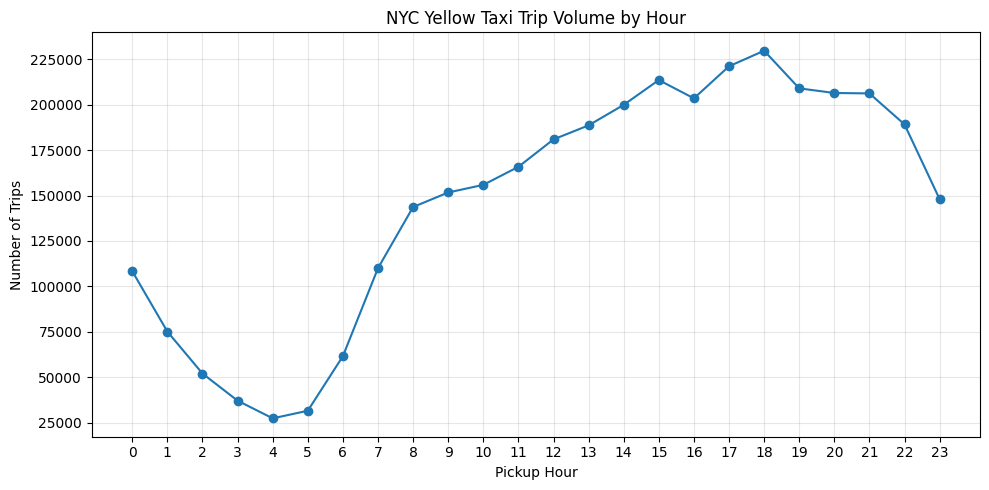

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand["pickup_hour"],
    hourly_demand["trip_count"],
    marker="o"
)

plt.title("NYC Yellow Taxi Trip Volume by Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

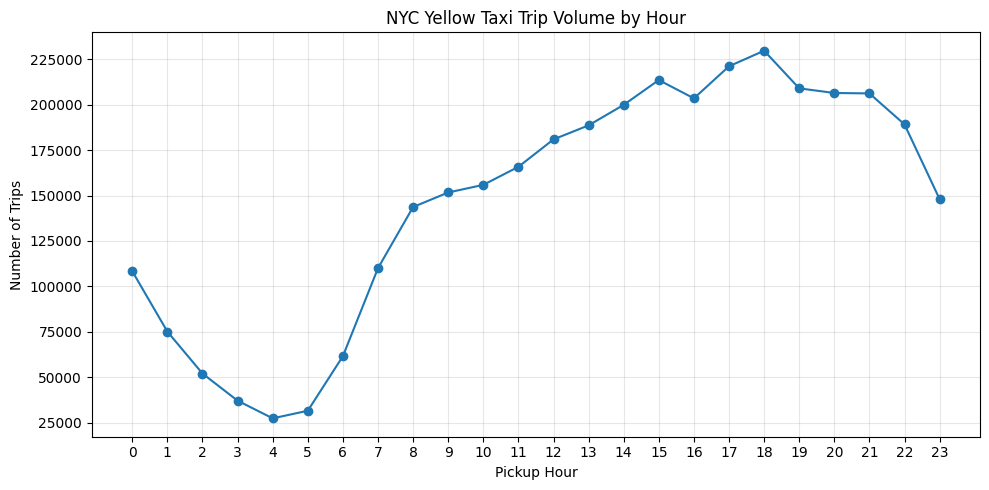

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand["pickup_hour"],
    hourly_demand["trip_count"],
    marker="o"
)

plt.title("NYC Yellow Taxi Trip Volume by Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/hourly_trip_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
query = """
SELECT
    EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS trip_count
FROM final_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 5;
"""

con.execute(query).df()

,pickup_hour,trip_count
0,18,229572
1,17,221027
2,15,213453
3,19,208881
4,20,206342


In [37]:
query = """
SELECT
    CASE
        WHEN EXTRACT(DOW FROM tpep_pickup_datetime) IN (0, 6)
            THEN 'Weekend'
        ELSE 'Weekday'
    END AS day_type,

    EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,

    COUNT(*) AS trip_count

FROM final_trips

GROUP BY day_type, pickup_hour

ORDER BY day_type, pickup_hour;
"""

weekday_weekend = con.execute(query).df()

weekday_weekend

,day_type,pickup_hour,trip_count
0,Weekday,0,52428
1,Weekday,1,31810
2,Weekday,2,20576
3,Weekday,3,15494
4,Weekday,4,14779
5,Weekday,5,24682
6,Weekday,6,51425
7,Weekday,7,95858
8,Weekday,8,122216
9,Weekday,9,120700


In [38]:
query = """
WITH daily_hourly AS (
    SELECT
        CAST(tpep_pickup_datetime AS DATE) AS trip_date,

        CASE
            WHEN EXTRACT(DOW FROM tpep_pickup_datetime) IN (0, 6)
                THEN 'Weekend'
            ELSE 'Weekday'
        END AS day_type,

        EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,

        COUNT(*) AS trip_count

    FROM final_trips

    GROUP BY trip_date, day_type, pickup_hour
)

SELECT
    day_type,
    pickup_hour,
    ROUND(AVG(trip_count), 0) AS avg_daily_trips

FROM daily_hourly

GROUP BY day_type, pickup_hour

ORDER BY day_type, pickup_hour;
"""

normalized_demand = con.execute(query).df()

normalized_demand

,day_type,pickup_hour,avg_daily_trips
0,Weekday,0,2383.0
1,Weekday,1,1446.0
2,Weekday,2,935.0
3,Weekday,3,704.0
4,Weekday,4,672.0
5,Weekday,5,1122.0
6,Weekday,6,2338.0
7,Weekday,7,4357.0
8,Weekday,8,5555.0
9,Weekday,9,5486.0


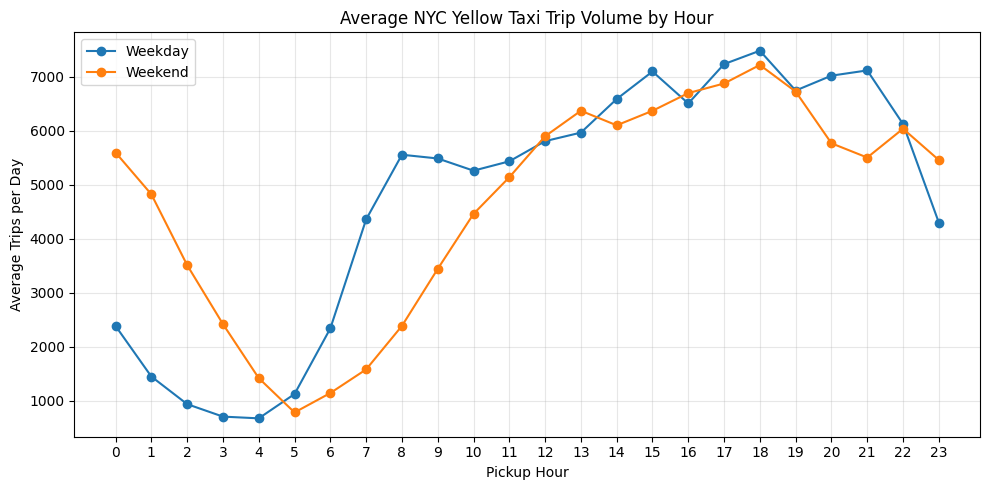

In [39]:
import matplotlib.pyplot as plt

weekday_data = normalized_demand[
    normalized_demand["day_type"] == "Weekday"
]

weekend_data = normalized_demand[
    normalized_demand["day_type"] == "Weekend"
]

plt.figure(figsize=(10, 5))

plt.plot(
    weekday_data["pickup_hour"],
    weekday_data["avg_daily_trips"],
    marker="o",
    label="Weekday"
)

plt.plot(
    weekend_data["pickup_hour"],
    weekend_data["avg_daily_trips"],
    marker="o",
    label="Weekend"
)

plt.title("Average NYC Yellow Taxi Trip Volume by Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Average Trips per Day")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
zone_lookup = pd.read_csv('/content/taxi_zone_lookup.csv')

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [41]:
con.register("zone_lookup", zone_lookup)

In [42]:
query = """
SELECT
    z.Borough,
    z.Zone,
    COUNT(*) AS trip_count

FROM final_trips t

LEFT JOIN zone_lookup z
    ON t.PULocationID = z.LocationID

GROUP BY z.Borough, z.Zone

ORDER BY trip_count DESC

LIMIT 15;
"""

top_pickup_zones = con.execute(query).df()

top_pickup_zones

,Borough,Zone,trip_count
0,Manhattan,Upper East Side South,152502
1,Manhattan,Upper East Side North,145680
2,Queens,JFK Airport,141476
3,Manhattan,Midtown Center,139198
4,Manhattan,Penn Station/Madison Sq West,105622
5,Manhattan,Lincoln Square East,104655
6,Manhattan,Midtown East,103653
7,Manhattan,Times Sq/Theatre District,100825
8,Manhattan,East Village,96366
9,Manhattan,Upper West Side South,92395


In [43]:
query = """
SELECT
    z.Borough,
    COUNT(*) AS trip_count,

    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS trip_share_pct

FROM final_trips t

LEFT JOIN zone_lookup z
    ON t.PULocationID = z.LocationID

GROUP BY z.Borough

ORDER BY trip_count DESC;
"""

borough_share = con.execute(query).df()

borough_share

,Borough,trip_count,trip_share_pct
0,Manhattan,3008941,85.58
1,Queens,320375,9.11
2,Brooklyn,146169,4.16
3,Bronx,35149,1.00
4,Unknown,4079,0.12
5,None,663,0.02
6,Staten Island,454,0.01
7,EWR,110,0.00


In [44]:
zone_lookup[
    (zone_lookup["Borough"] == "Unknown") |
    (zone_lookup["Zone"] == "Unknown")
]

,LocationID,Borough,Zone,service_zone
263,264,Unknown,NaN,NaN


In [45]:
query = """
SELECT
    COUNT(*) AS total_trips,

    SUM(
        CASE
            WHEN z.LocationID IS NULL THEN 1
            ELSE 0
        END
    ) AS unmatched_trips,

    ROUND(
        SUM(
            CASE
                WHEN z.LocationID IS NULL THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        4
    ) AS unmatched_pct

FROM final_trips t

LEFT JOIN zone_lookup z
    ON t.PULocationID = z.LocationID;
"""

con.execute(query).df()

,total_trips,unmatched_trips,unmatched_pct
0,3515940,0.0,0.0


In [46]:
query = """
SELECT
    z.Borough,
    z.Zone,

    COUNT(*) AS trip_count,

    ROUND(
        MEDIAN(t.total_amount),
        2
    ) AS median_total_amount,

    ROUND(
        MEDIAN(t.duration_min),
        2
    ) AS median_duration_min,

    ROUND(
        MEDIAN(t.trip_distance),
        2
    ) AS median_trip_distance,

    ROUND(
        SUM(
            CASE
                WHEN EXTRACT(DOW FROM t.tpep_pickup_datetime) IN (0, 6)
                THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*),
        2
    ) AS weekend_share_pct

FROM final_trips t

LEFT JOIN zone_lookup z
    ON t.PULocationID = z.LocationID

WHERE z.Zone IS NOT NULL

GROUP BY
    z.Borough,
    z.Zone

ORDER BY trip_count DESC

LIMIT 15;
"""

zone_metrics = con.execute(query).df()

zone_metrics

,Borough,Zone,trip_count,median_total_amount,median_duration_min,median_trip_distance,weekend_share_pct
0,Manhattan,Upper East Side South,152502,18.40,9.67,1.23,21.57
1,Manhattan,Upper East Side North,145680,18.96,10.35,1.41,21.71
2,Queens,JFK Airport,141476,86.50,37.27,16.96,28.05
3,Manhattan,Midtown Center,139198,22.38,12.85,1.54,19.59
4,Manhattan,Penn Station/Madison Sq West,105622,22.26,13.67,1.50,28.61
5,Manhattan,Lincoln Square East,104655,20.16,10.83,1.61,28.59
6,Manhattan,Midtown East,103653,21.90,12.57,1.53,19.10
7,Manhattan,Times Sq/Theatre District,100825,22.85,13.02,1.60,28.92
8,Manhattan,East Village,96366,22.26,12.23,1.80,46.16
9,Manhattan,Upper West Side South,92395,19.95,10.75,1.65,29.32


In [47]:
query = """
WITH zone_stats AS (
    SELECT
        z.Borough,
        z.Zone,

        COUNT(*) AS total_trips,

        SUM(
            CASE
                WHEN EXTRACT(HOUR FROM t.tpep_pickup_datetime) >= 22
                  OR EXTRACT(HOUR FROM t.tpep_pickup_datetime) < 4
                THEN 1
                ELSE 0
            END
        ) AS late_night_trips

    FROM final_trips t

    LEFT JOIN zone_lookup z
        ON t.PULocationID = z.LocationID

    WHERE z.Zone IS NOT NULL

    GROUP BY
        z.Borough,
        z.Zone
),

citywide AS (
    SELECT
        SUM(late_night_trips) * 1.0 /
        SUM(total_trips) AS citywide_late_night_share
    FROM zone_stats
)

SELECT
    zs.Borough,
    zs.Zone,
    zs.total_trips,

    ROUND(
        zs.late_night_trips * 100.0 / zs.total_trips,
        2
    ) AS late_night_share_pct,

    ROUND(
        (zs.late_night_trips * 1.0 / zs.total_trips)
        / c.citywide_late_night_share,
        2
    ) AS late_night_index

FROM zone_stats zs
CROSS JOIN citywide c

WHERE zs.total_trips >= 10000

ORDER BY late_night_index DESC

LIMIT 15;
"""

late_night_zones = con.execute(query).df()

late_night_zones

,Borough,Zone,total_trips,late_night_share_pct,late_night_index
0,Manhattan,Lower East Side,45037,50.90,2.93
1,Manhattan,Greenwich Village South,50454,47.58,2.74
2,Manhattan,East Village,96366,42.19,2.43
3,Manhattan,Alphabet City,15594,39.98,2.30
4,Manhattan,West Village,76122,39.79,2.29
5,Manhattan,Meatpacking/West Village West,31284,34.13,1.97
6,Manhattan,Little Italy/NoLiTa,37362,32.36,1.86
7,Manhattan,Financial District North,23116,25.87,1.49
8,Manhattan,Clinton East,78695,24.93,1.44
9,Manhattan,SoHo,26498,24.59,1.42


In [48]:
query = """
WITH zone_hourly AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS hourly_trips
    FROM final_trips t
    LEFT JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
    GROUP BY
        z.Borough,
        z.Zone,
        pickup_hour
),

zone_totals AS (
    SELECT
        Borough,
        Zone,
        SUM(hourly_trips) AS total_trips,
        MAX(hourly_trips) AS peak_hour_trips,
        AVG(hourly_trips) AS avg_hourly_trips
    FROM zone_hourly
    GROUP BY Borough, Zone
),

peak_hours AS (
    SELECT
        Borough,
        Zone,
        pickup_hour,
        hourly_trips,
        ROW_NUMBER() OVER (
            PARTITION BY Borough, Zone
            ORDER BY hourly_trips DESC
        ) AS rn
    FROM zone_hourly
)

SELECT
    zt.Borough,
    zt.Zone,
    zt.total_trips,
    ph.pickup_hour AS peak_hour,
    ph.hourly_trips AS peak_hour_trips,

    ROUND(
        ph.hourly_trips * 100.0 / zt.total_trips,
        2
    ) AS peak_hour_share_pct,

    ROUND(
        ph.hourly_trips * 1.0 / zt.avg_hourly_trips,
        2
    ) AS peak_to_average_ratio

FROM zone_totals zt

JOIN peak_hours ph
    ON zt.Borough = ph.Borough
    AND zt.Zone = ph.Zone
    AND ph.rn = 1

WHERE zt.total_trips >= 20000

ORDER BY peak_to_average_ratio DESC

LIMIT 20;
"""

zone_peak_concentration = con.execute(query).df()

zone_peak_concentration

,Borough,Zone,total_trips,peak_hour,peak_hour_trips,peak_hour_share_pct,peak_to_average_ratio
0,Manhattan,Times Sq/Theatre District,100825.0,21,10693,10.61,2.55
1,Manhattan,Central Park,41173.0,15,4138,10.05,2.41
2,Manhattan,Greenwich Village South,50454.0,23,5034,9.98,2.39
3,Manhattan,Lower East Side,45037.0,1,4359,9.68,2.32
4,Manhattan,Midtown East,103653.0,18,9547,9.21,2.21
5,Manhattan,West Village,76122.0,23,6966,9.15,2.20
6,Manhattan,Midtown North,81586.0,18,7246,8.88,2.13
7,Manhattan,Midtown Center,139198.0,18,12293,8.83,2.12
8,Manhattan,Upper East Side North,145680.0,15,12785,8.78,2.11
9,Manhattan,Battery Park City,20499.0,18,1789,8.73,2.09


In [1]:
con.execute("SELECT COUNT(*) FROM final_trips").df()

NameError: name 'con' is not defined

In [2]:
!pip install duckdb -q

import duckdb
import pandas as pd

# Create SQL connection
con = duckdb.connect()

# Load zone lookup table
zone_lookup = pd.read_csv('/content/taxi_zone_lookup.csv')
con.register("zone_lookup", zone_lookup)

# Step 1: Basic logical cleaning
con.execute("""
CREATE OR REPLACE VIEW clean_trips AS

SELECT *
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet')

WHERE trip_distance > 0
  AND fare_amount >= 0
  AND tpep_dropoff_datetime > tpep_pickup_datetime;
""")

# Step 2: Create duration and speed metrics,
# then remove impossible-speed trips
con.execute("""
CREATE OR REPLACE VIEW analysis_trips AS

WITH trip_metrics AS (
    SELECT
        *,
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0 AS duration_min

    FROM clean_trips
)

SELECT
    *,
    trip_distance / (duration_min / 60.0) AS avg_speed_mph

FROM trip_metrics

WHERE duration_min > 0
  AND trip_distance / (duration_min / 60.0) <= 80;
""")

# Step 3: Final analytical sample
con.execute("""
CREATE OR REPLACE VIEW final_trips AS

SELECT *
FROM analysis_trips

WHERE total_amount >= 0
  AND duration_min <= 240;
""")

# Validate
con.execute("""
SELECT COUNT(*) AS final_trip_count
FROM final_trips;
""").df()

InvalidInputException: Invalid Input Error: No magic bytes found at end of file '/content/yellow_tripdata_2026-01.parquet'

In [3]:
import os

path = "/content/yellow_tripdata_2026-01.parquet"

print("File size:", os.path.getsize(path))

with open(path, "rb") as f:
    print("Start:", f.read(4))
    f.seek(-4, 2)
    print("End:", f.read(4))

File size: 64165080
Start: b'PAR1'
End: b'PAR1'


In [4]:
import duckdb

con = duckdb.connect()

test = con.execute("""
SELECT COUNT(*) AS total_trips
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet')
""").df()

test

,total_trips
0,3724889


In [5]:
import pandas as pd
import duckdb

# 1. SQL connection
con = duckdb.connect()

# 2. Load zone lookup
zone_lookup = pd.read_csv('/content/taxi_zone_lookup.csv')
con.register("zone_lookup", zone_lookup)

# 3. Basic cleaning
con.execute("""
CREATE OR REPLACE VIEW clean_trips AS
SELECT *
FROM read_parquet('/content/yellow_tripdata_2026-01.parquet')
WHERE trip_distance > 0
  AND fare_amount >= 0
  AND tpep_dropoff_datetime > tpep_pickup_datetime;
""")

# 4. Add duration + speed, remove impossible speeds
con.execute("""
CREATE OR REPLACE VIEW analysis_trips AS
WITH trip_metrics AS (
    SELECT
        *,
        DATE_DIFF(
            'second',
            tpep_pickup_datetime,
            tpep_dropoff_datetime
        ) / 60.0 AS duration_min
    FROM clean_trips
)

SELECT
    *,
    trip_distance / (duration_min / 60.0) AS avg_speed_mph

FROM trip_metrics

WHERE duration_min > 0
  AND trip_distance / (duration_min / 60.0) <= 80;
""")

# 5. Final analytical sample
con.execute("""
CREATE OR REPLACE VIEW final_trips AS
SELECT *
FROM analysis_trips
WHERE total_amount >= 0
  AND duration_min <= 240;
""")

# 6. Validate
con.execute("""
SELECT COUNT(*) AS final_trip_count
FROM final_trips;
""").df()

,final_trip_count
0,3515940


In [6]:
query = """
WITH zone_hourly AS (

    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS hourly_trips

    FROM final_trips t

    LEFT JOIN zone_lookup z
        ON t.PULocationID = z.LocationID

    WHERE z.Zone IS NOT NULL

    GROUP BY
        z.Borough,
        z.Zone,
        pickup_hour
),

zone_summary AS (

    SELECT
        Borough,
        Zone,
        SUM(hourly_trips) AS total_trips,
        AVG(hourly_trips) AS avg_hourly_trips

    FROM zone_hourly

    GROUP BY
        Borough,
        Zone
),

ranked_hours AS (

    SELECT
        Borough,
        Zone,
        pickup_hour,
        hourly_trips,

        ROW_NUMBER() OVER (
            PARTITION BY Borough, Zone
            ORDER BY hourly_trips DESC
        ) AS hour_rank

    FROM zone_hourly
)

SELECT
    zs.Borough,
    zs.Zone,
    zs.total_trips,
    rh.pickup_hour AS peak_hour,
    rh.hourly_trips AS peak_hour_trips,

    ROUND(
        rh.hourly_trips * 100.0 / zs.total_trips,
        2
    ) AS peak_hour_share_pct,

    ROUND(
        rh.hourly_trips * 1.0 / zs.avg_hourly_trips,
        2
    ) AS peak_to_average_ratio

FROM zone_summary zs

JOIN ranked_hours rh
    ON zs.Borough = rh.Borough
    AND zs.Zone = rh.Zone
    AND rh.hour_rank = 1

WHERE zs.total_trips >= 20000

ORDER BY peak_to_average_ratio DESC

LIMIT 20;
"""

zone_peak_analysis = con.execute(query).df()

zone_peak_analysis

,Borough,Zone,total_trips,peak_hour,peak_hour_trips,peak_hour_share_pct,peak_to_average_ratio
0,Manhattan,Times Sq/Theatre District,100825.0,21,10693,10.61,2.55
1,Manhattan,Central Park,41173.0,15,4138,10.05,2.41
2,Manhattan,Greenwich Village South,50454.0,23,5034,9.98,2.39
3,Manhattan,Lower East Side,45037.0,1,4359,9.68,2.32
4,Manhattan,Midtown East,103653.0,18,9547,9.21,2.21
5,Manhattan,West Village,76122.0,23,6966,9.15,2.20
6,Manhattan,Midtown North,81586.0,18,7246,8.88,2.13
7,Manhattan,Midtown Center,139198.0,18,12293,8.83,2.12
8,Manhattan,Upper East Side North,145680.0,15,12785,8.78,2.11
9,Manhattan,Battery Park City,20499.0,18,1789,8.73,2.09


In [7]:
query = """
WITH zone_hourly AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS zone_hour_trips
    FROM final_trips t
    LEFT JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
    GROUP BY z.Borough, z.Zone, pickup_hour
),

zone_totals AS (
    SELECT
        Borough,
        Zone,
        SUM(zone_hour_trips) AS zone_total_trips
    FROM zone_hourly
    GROUP BY Borough, Zone
),

city_hourly AS (
    SELECT
        EXTRACT(HOUR FROM tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS city_hour_trips
    FROM final_trips
    GROUP BY pickup_hour
),

city_total AS (
    SELECT COUNT(*) AS city_total_trips
    FROM final_trips
),

indexed AS (
    SELECT
        zh.Borough,
        zh.Zone,
        zh.pickup_hour,
        zt.zone_total_trips,

        zh.zone_hour_trips,

        zh.zone_hour_trips * 1.0
            / zt.zone_total_trips AS zone_hour_share,

        ch.city_hour_trips * 1.0
            / ct.city_total_trips AS city_hour_share,

        (
            zh.zone_hour_trips * 1.0 / zt.zone_total_trips
        ) /
        (
            ch.city_hour_trips * 1.0 / ct.city_total_trips
        ) AS hourly_index

    FROM zone_hourly zh

    JOIN zone_totals zt
        ON zh.Borough = zt.Borough
        AND zh.Zone = zt.Zone

    JOIN city_hourly ch
        ON zh.pickup_hour = ch.pickup_hour

    CROSS JOIN city_total ct

    WHERE zt.zone_total_trips >= 20000
),

ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY Borough, Zone
            ORDER BY hourly_index DESC
        ) AS rn
    FROM indexed
)

SELECT
    Borough,
    Zone,
    zone_total_trips,
    pickup_hour AS most_overindexed_hour,

    ROUND(zone_hour_share * 100, 2) AS zone_hour_share_pct,
    ROUND(city_hour_share * 100, 2) AS city_hour_share_pct,
    ROUND(hourly_index, 2) AS hourly_overindex

FROM ranked

WHERE rn = 1

ORDER BY hourly_overindex DESC

LIMIT 20;
"""

zone_hour_overindex = con.execute(query).df()

zone_hour_overindex

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Borough,Zone,zone_total_trips,most_overindexed_hour,zone_hour_share_pct,city_hour_share_pct,hourly_overindex
0,Manhattan,Lower East Side,45037.0,2,8.31,1.48,5.60
1,Manhattan,Greenwich Village South,50454.0,2,6.06,1.48,4.08
2,Manhattan,East Village,96366.0,2,5.81,1.48,3.91
3,Manhattan,Little Italy/NoLiTa,37362.0,3,3.81,1.06,3.59
4,Manhattan,West Village,76122.0,1,6.54,2.14,3.06
5,Manhattan,Meatpacking/West Village West,31284.0,2,3.96,1.48,2.67
6,Manhattan,Clinton East,78695.0,4,1.81,0.78,2.31
7,Manhattan,Garment District,43722.0,5,1.91,0.90,2.12
8,Manhattan,Yorkville East,51863.0,7,6.31,3.13,2.02
9,Queens,JFK Airport,141476.0,5,1.79,0.90,1.99


In [8]:
query = """
WITH pickups AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups
    FROM final_trips t
    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
    GROUP BY z.Borough, z.Zone, hour
),

dropoffs AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_dropoff_datetime) AS hour,
        COUNT(*) AS dropoffs
    FROM final_trips t
    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
    GROUP BY z.Borough, z.Zone, hour
)

SELECT
    p.Borough,
    p.Zone,
    p.hour,
    p.pickups,
    d.dropoffs,

    p.pickups - d.dropoffs AS net_pickups,

    ROUND(
        (p.pickups - d.dropoffs) * 1.0
        / (p.pickups + d.dropoffs),
        3
    ) AS imbalance_index

FROM pickups p

JOIN dropoffs d
    ON p.Borough = d.Borough
    AND p.Zone = d.Zone
    AND p.hour = d.hour

WHERE p.pickups + d.dropoffs >= 5000

ORDER BY imbalance_index DESC

LIMIT 20;
"""

imbalance_analysis = con.execute(query).df()

imbalance_analysis

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Borough,Zone,hour,pickups,dropoffs,net_pickups,imbalance_index
0,Queens,LaGuardia Airport,23,5033,80,4953,0.969
1,Queens,JFK Airport,0,5937,142,5795,0.953
2,Queens,JFK Airport,23,8713,212,8501,0.952
3,Queens,LaGuardia Airport,21,5606,163,5443,0.943
4,Queens,JFK Airport,22,9698,356,9342,0.929
5,Queens,LaGuardia Airport,20,5581,264,5317,0.910
6,Queens,JFK Airport,21,9877,500,9377,0.904
7,Queens,JFK Airport,20,11185,745,10440,0.875
8,Queens,LaGuardia Airport,19,5347,541,4806,0.816
9,Queens,JFK Airport,19,9956,1101,8855,0.801


In [9]:
query = """
WITH pickups AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups
    FROM final_trips t
    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
      AND z.Zone IS NOT NULL
    GROUP BY z.Borough, z.Zone, hour
),

dropoffs AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_dropoff_datetime) AS hour,
        COUNT(*) AS dropoffs
    FROM final_trips t
    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID
    WHERE z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
      AND z.Zone IS NOT NULL
    GROUP BY z.Borough, z.Zone, hour
)

SELECT
    p.Borough,
    p.Zone,
    p.hour,
    p.pickups,
    d.dropoffs,

    p.pickups - d.dropoffs AS net_pickups,

    ROUND(
        (p.pickups - d.dropoffs) * 1.0
        / (p.pickups + d.dropoffs),
        3
    ) AS imbalance_index

FROM pickups p

JOIN dropoffs d
    ON p.Borough = d.Borough
    AND p.Zone = d.Zone
    AND p.hour = d.hour

WHERE p.pickups + d.dropoffs >= 5000

ORDER BY imbalance_index DESC

LIMIT 20;
"""

urban_imbalance = con.execute(query).df()

urban_imbalance

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Borough,Zone,hour,pickups,dropoffs,net_pickups,imbalance_index
0,Manhattan,Greenwich Village South,1,4346,1204,3142,0.566
1,Manhattan,Midtown Center,21,10522,3592,6930,0.491
2,Manhattan,Midtown Center,20,11179,3897,7282,0.483
3,Manhattan,Greenwich Village South,0,5032,1800,3232,0.473
4,Manhattan,Yorkville East,9,3891,1416,2475,0.466
5,Manhattan,Lower East Side,2,3744,1419,2325,0.450
6,Manhattan,West Village,1,4980,1980,3000,0.431
7,Manhattan,Times Sq/Theatre District,21,10693,4343,6350,0.422
8,Manhattan,Yorkville East,8,3655,1507,2148,0.416
9,Manhattan,Times Sq/Theatre District,22,9607,4024,5583,0.410


In [10]:
query = """
WITH pickups AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups
    FROM final_trips t
    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
      AND z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
    GROUP BY z.Borough, z.Zone, hour
),

dropoffs AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_dropoff_datetime) AS hour,
        COUNT(*) AS dropoffs
    FROM final_trips t
    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
      AND z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
    GROUP BY z.Borough, z.Zone, hour
),

hourly_imbalance AS (
    SELECT
        p.Borough,
        p.Zone,
        p.hour,
        p.pickups,
        d.dropoffs,
        p.pickups + d.dropoffs AS total_activity,

        (p.pickups - d.dropoffs) * 1.0
        / (p.pickups + d.dropoffs) AS imbalance_index

    FROM pickups p
    JOIN dropoffs d
        ON p.Borough = d.Borough
        AND p.Zone = d.Zone
        AND p.hour = d.hour

    WHERE p.pickups + d.dropoffs >= 3000
)

SELECT
    ROUND(MEDIAN(imbalance_index), 3) AS median_imbalance,
    ROUND(QUANTILE_CONT(imbalance_index, 0.75), 3) AS p75_imbalance,
    ROUND(QUANTILE_CONT(imbalance_index, 0.90), 3) AS p90_imbalance,
    ROUND(QUANTILE_CONT(imbalance_index, 0.95), 3) AS p95_imbalance,
    ROUND(MAX(imbalance_index), 3) AS max_imbalance,
    COUNT(*) AS qualifying_zone_hours

FROM hourly_imbalance;
"""

imbalance_distribution = con.execute(query).df()

imbalance_distribution

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,median_imbalance,p75_imbalance,p90_imbalance,p95_imbalance,max_imbalance,qualifying_zone_hours
0,0.005,0.102,0.261,0.335,0.616,669


In [11]:
query = """
WITH pickups AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups
    FROM final_trips t
    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
      AND z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
    GROUP BY z.Borough, z.Zone, hour
),

dropoffs AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_dropoff_datetime) AS hour,
        COUNT(*) AS dropoffs
    FROM final_trips t
    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
      AND z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
    GROUP BY z.Borough, z.Zone, hour
),

hourly_imbalance AS (
    SELECT
        p.Borough,
        p.Zone,
        p.hour,
        p.pickups,
        d.dropoffs,
        p.pickups + d.dropoffs AS total_activity,

        (p.pickups - d.dropoffs) * 1.0
        / (p.pickups + d.dropoffs) AS imbalance_index

    FROM pickups p

    JOIN dropoffs d
        ON p.Borough = d.Borough
        AND p.Zone = d.Zone
        AND p.hour = d.hour

    WHERE p.pickups + d.dropoffs >= 3000
),

high_pressure AS (
    SELECT *
    FROM hourly_imbalance
    WHERE imbalance_index >= 0.261
),

-- Duplicate hours so sequences such as 23, 0, 1
-- can be recognized as consecutive across midnight
expanded_hours AS (
    SELECT
        *,
        hour AS hour_ext
    FROM high_pressure

    UNION ALL

    SELECT
        *,
        hour + 24 AS hour_ext
    FROM high_pressure
),

numbered AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY Borough, Zone
            ORDER BY hour_ext
        ) AS rn
    FROM expanded_hours
),

islands AS (
    SELECT
        *,
        hour_ext - rn AS island_id
    FROM numbered
),

windows AS (
    SELECT
        Borough,
        Zone,
        MIN(hour_ext) AS start_hour_ext,
        MAX(hour_ext) AS end_hour_ext,

        COUNT(*) AS consecutive_hours,

        ROUND(AVG(imbalance_index), 3)
            AS avg_imbalance_index,

        SUM(pickups) AS total_pickups,
        SUM(dropoffs) AS total_dropoffs

    FROM islands

    GROUP BY
        Borough,
        Zone,
        island_id
),

ranked AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY Borough, Zone
            ORDER BY
                consecutive_hours DESC,
                avg_imbalance_index DESC
        ) AS window_rank

    FROM windows

    WHERE start_hour_ext < 24
      AND consecutive_hours >= 2
)

SELECT
    Borough,
    Zone,

    MOD(start_hour_ext, 24) AS start_hour,
    MOD(end_hour_ext, 24) AS end_hour,

    consecutive_hours,
    avg_imbalance_index,
    total_pickups,
    total_dropoffs,

    ROUND(
        total_pickups * 1.0 / total_dropoffs,
        2
    ) AS pickup_to_dropoff_ratio

FROM ranked

WHERE window_rank = 1

ORDER BY
    consecutive_hours DESC,
    avg_imbalance_index DESC;
"""

persistent_pressure = con.execute(query).df()

persistent_pressure

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Borough,Zone,start_hour,end_hour,consecutive_hours,avg_imbalance_index,total_pickups,total_dropoffs,pickup_to_dropoff_ratio
0,Manhattan,Midtown Center,17,0,8,0.379,70735.0,31896.0,2.22
1,Manhattan,Penn Station/Madison Sq West,6,13,8,0.334,39913.0,20456.0,1.95
2,Manhattan,Greenwich Village South,22,2,5,0.455,22248.0,8911.0,2.50
3,Manhattan,Midtown East,17,21,5,0.305,40700.0,21655.0,1.88
4,Manhattan,Yorkville East,7,10,4,0.449,14568.0,5626.0,2.59
5,Manhattan,West Village,23,2,4,0.383,21305.0,9859.0,2.16
6,Manhattan,Lower East Side,1,3,3,0.431,10694.0,4366.0,2.45
7,Manhattan,Lincoln Square East,21,23,3,0.337,22343.0,11237.0,1.99
8,Manhattan,East Village,1,3,3,0.331,16746.0,8632.0,1.94
9,Manhattan,Central Park,15,17,3,0.298,12126.0,6559.0,1.85


In [12]:
query = """
WITH pickup_daily AS (
    SELECT
        CASE
            WHEN EXTRACT(HOUR FROM t.tpep_pickup_datetime) <= 2
                THEN CAST(t.tpep_pickup_datetime AS DATE) - INTERVAL 1 DAY
            ELSE CAST(t.tpep_pickup_datetime AS DATE)
        END AS service_date,

        COUNT(*) AS pickups

    FROM final_trips t

    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID

    WHERE z.Zone = 'Greenwich Village South'
      AND (
            EXTRACT(HOUR FROM t.tpep_pickup_datetime) >= 22
            OR EXTRACT(HOUR FROM t.tpep_pickup_datetime) <= 2
          )

    GROUP BY service_date
),

dropoff_daily AS (
    SELECT
        CASE
            WHEN EXTRACT(HOUR FROM t.tpep_dropoff_datetime) <= 2
                THEN CAST(t.tpep_dropoff_datetime AS DATE) - INTERVAL 1 DAY
            ELSE CAST(t.tpep_dropoff_datetime AS DATE)
        END AS service_date,

        COUNT(*) AS dropoffs

    FROM final_trips t

    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID

    WHERE z.Zone = 'Greenwich Village South'
      AND (
            EXTRACT(HOUR FROM t.tpep_dropoff_datetime) >= 22
            OR EXTRACT(HOUR FROM t.tpep_dropoff_datetime) <= 2
          )

    GROUP BY service_date
),

daily_balance AS (
    SELECT
        COALESCE(p.service_date, d.service_date) AS service_date,
        COALESCE(p.pickups, 0) AS pickups,
        COALESCE(d.dropoffs, 0) AS dropoffs,

        (
            COALESCE(p.pickups, 0) - COALESCE(d.dropoffs, 0)
        ) * 1.0
        /
        NULLIF(
            COALESCE(p.pickups, 0) + COALESCE(d.dropoffs, 0),
            0
        ) AS daily_imbalance

    FROM pickup_daily p

    FULL OUTER JOIN dropoff_daily d
        ON p.service_date = d.service_date
)

SELECT *
FROM daily_balance
ORDER BY service_date;
"""

greenwich_daily = con.execute(query).df()

greenwich_daily

,service_date,pickups,dropoffs,daily_imbalance
0,2025-12-31,629,236,0.454335
1,2026-01-01,316,108,0.490566
2,2026-01-02,858,329,0.445661
3,2026-01-03,1074,356,0.502098
4,2026-01-04,207,74,0.473310
5,2026-01-05,158,51,0.511962
6,2026-01-06,248,99,0.429395
7,2026-01-07,327,127,0.440529
8,2026-01-08,608,228,0.454545
9,2026-01-09,1696,632,0.457045


In [13]:
query = """
WITH daily AS (
    SELECT * FROM greenwich_daily
)

SELECT
    COUNT(*) AS days_observed,

    ROUND(AVG(daily_imbalance), 3) AS avg_daily_imbalance,

    ROUND(MEDIAN(daily_imbalance), 3) AS median_daily_imbalance,

    ROUND(
        QUANTILE_CONT(daily_imbalance, 0.25),
        3
    ) AS p25_daily_imbalance,

    ROUND(
        QUANTILE_CONT(daily_imbalance, 0.75),
        3
    ) AS p75_daily_imbalance,

    SUM(
        CASE WHEN daily_imbalance > 0
        THEN 1 ELSE 0 END
    ) AS pickup_heavy_days,

    ROUND(
        SUM(
            CASE WHEN daily_imbalance > 0
            THEN 1 ELSE 0 END
        ) * 100.0 / COUNT(*),
        1
    ) AS pickup_heavy_day_pct

FROM daily;
"""

con.execute(query).df()

,days_observed,avg_daily_imbalance,median_daily_imbalance,p25_daily_imbalance,p75_daily_imbalance,pickup_heavy_days,pickup_heavy_day_pct
0,32,0.425,0.45,0.405,0.463,32.0,100.0


In [14]:
query = """
WITH windows AS (
    SELECT *
    FROM (
        VALUES
            (
                'Greenwich Village South',
                22, 2,
                DATE '2026-01-01',
                DATE '2026-01-30'
            ),
            (
                'Midtown Center',
                17, 0,
                DATE '2026-01-01',
                DATE '2026-01-30'
            ),
            (
                'Penn Station/Madison Sq West',
                6, 13,
                DATE '2026-01-01',
                DATE '2026-01-31'
            )
    ) AS t(
        zone_name,
        start_hour,
        end_hour,
        complete_start_date,
        complete_end_date
    )
),

pickup_labeled AS (
    SELECT
        w.zone_name,

        CASE
            WHEN w.start_hour > w.end_hour
                 AND EXTRACT(HOUR FROM t.tpep_pickup_datetime) <= w.end_hour
            THEN CAST(t.tpep_pickup_datetime AS DATE) - INTERVAL 1 DAY

            ELSE CAST(t.tpep_pickup_datetime AS DATE)
        END AS service_date,

        w.complete_start_date,
        w.complete_end_date

    FROM final_trips t

    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID

    JOIN windows w
        ON z.Zone = w.zone_name

    WHERE
        (
            w.start_hour <= w.end_hour
            AND EXTRACT(HOUR FROM t.tpep_pickup_datetime)
                BETWEEN w.start_hour AND w.end_hour
        )
        OR
        (
            w.start_hour > w.end_hour
            AND (
                EXTRACT(HOUR FROM t.tpep_pickup_datetime) >= w.start_hour
                OR EXTRACT(HOUR FROM t.tpep_pickup_datetime) <= w.end_hour
            )
        )
),

pickup_daily AS (
    SELECT
        zone_name,
        service_date,
        COUNT(*) AS pickups

    FROM pickup_labeled

    WHERE service_date
          BETWEEN complete_start_date AND complete_end_date

    GROUP BY zone_name, service_date
),

dropoff_labeled AS (
    SELECT
        w.zone_name,

        CASE
            WHEN w.start_hour > w.end_hour
                 AND EXTRACT(HOUR FROM t.tpep_dropoff_datetime) <= w.end_hour
            THEN CAST(t.tpep_dropoff_datetime AS DATE) - INTERVAL 1 DAY

            ELSE CAST(t.tpep_dropoff_datetime AS DATE)
        END AS service_date,

        w.complete_start_date,
        w.complete_end_date

    FROM final_trips t

    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID

    JOIN windows w
        ON z.Zone = w.zone_name

    WHERE
        (
            w.start_hour <= w.end_hour
            AND EXTRACT(HOUR FROM t.tpep_dropoff_datetime)
                BETWEEN w.start_hour AND w.end_hour
        )
        OR
        (
            w.start_hour > w.end_hour
            AND (
                EXTRACT(HOUR FROM t.tpep_dropoff_datetime) >= w.start_hour
                OR EXTRACT(HOUR FROM t.tpep_dropoff_datetime) <= w.end_hour
            )
        )
),

dropoff_daily AS (
    SELECT
        zone_name,
        service_date,
        COUNT(*) AS dropoffs

    FROM dropoff_labeled

    WHERE service_date
          BETWEEN complete_start_date AND complete_end_date

    GROUP BY zone_name, service_date
),

daily_balance AS (
    SELECT
        COALESCE(p.zone_name, d.zone_name) AS zone_name,
        COALESCE(p.service_date, d.service_date) AS service_date,

        COALESCE(p.pickups, 0) AS pickups,
        COALESCE(d.dropoffs, 0) AS dropoffs,

        (
            COALESCE(p.pickups, 0)
            - COALESCE(d.dropoffs, 0)
        ) * 1.0
        /
        NULLIF(
            COALESCE(p.pickups, 0)
            + COALESCE(d.dropoffs, 0),
            0
        ) AS daily_imbalance

    FROM pickup_daily p

    FULL OUTER JOIN dropoff_daily d
        ON p.zone_name = d.zone_name
        AND p.service_date = d.service_date
)

SELECT
    zone_name,

    COUNT(*) AS days_observed,

    ROUND(AVG(daily_imbalance), 3)
        AS avg_daily_imbalance,

    ROUND(MEDIAN(daily_imbalance), 3)
        AS median_daily_imbalance,

    ROUND(
        QUANTILE_CONT(daily_imbalance, 0.25),
        3
    ) AS p25_daily_imbalance,

    ROUND(
        QUANTILE_CONT(daily_imbalance, 0.75),
        3
    ) AS p75_daily_imbalance,

    SUM(
        CASE WHEN daily_imbalance > 0
        THEN 1 ELSE 0 END
    ) AS pickup_heavy_days,

    ROUND(
        SUM(
            CASE WHEN daily_imbalance > 0
            THEN 1 ELSE 0 END
        ) * 100.0 / COUNT(*),
        1
    ) AS pickup_heavy_day_pct

FROM daily_balance

GROUP BY zone_name

ORDER BY median_daily_imbalance DESC;
"""

robustness_summary = con.execute(query).df()

robustness_summary

,zone_name,days_observed,avg_daily_imbalance,median_daily_imbalance,p25_daily_imbalance,p75_daily_imbalance,pickup_heavy_days,pickup_heavy_day_pct
0,Greenwich Village South,30,0.434,0.450,0.411,0.464,30.0,100.0
1,Midtown Center,30,0.344,0.395,0.170,0.493,30.0,100.0
2,Penn Station/Madison Sq West,31,0.301,0.315,0.220,0.399,30.0,96.8


In [15]:
daily_results = con.execute("""
WITH windows AS (
    SELECT *
    FROM (
        VALUES
            ('Greenwich Village South', 22, 2,
             DATE '2026-01-01', DATE '2026-01-30'),
            ('Midtown Center', 17, 0,
             DATE '2026-01-01', DATE '2026-01-30'),
            ('Penn Station/Madison Sq West', 6, 13,
             DATE '2026-01-01', DATE '2026-01-31')
    ) AS t(
        zone_name,
        start_hour,
        end_hour,
        complete_start_date,
        complete_end_date
    )
),

pickup_labeled AS (
    SELECT
        w.zone_name,
        CASE
            WHEN w.start_hour > w.end_hour
             AND EXTRACT(HOUR FROM t.tpep_pickup_datetime) <= w.end_hour
            THEN CAST(t.tpep_pickup_datetime AS DATE) - INTERVAL 1 DAY
            ELSE CAST(t.tpep_pickup_datetime AS DATE)
        END AS service_date,
        w.complete_start_date,
        w.complete_end_date
    FROM final_trips t
    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    JOIN windows w
        ON z.Zone = w.zone_name
    WHERE
        (w.start_hour <= w.end_hour
         AND EXTRACT(HOUR FROM t.tpep_pickup_datetime)
             BETWEEN w.start_hour AND w.end_hour)
        OR
        (w.start_hour > w.end_hour
         AND (
            EXTRACT(HOUR FROM t.tpep_pickup_datetime) >= w.start_hour
            OR EXTRACT(HOUR FROM t.tpep_pickup_datetime) <= w.end_hour
         ))
),

pickup_daily AS (
    SELECT zone_name, service_date, COUNT(*) AS pickups
    FROM pickup_labeled
    WHERE service_date BETWEEN complete_start_date AND complete_end_date
    GROUP BY zone_name, service_date
),

dropoff_labeled AS (
    SELECT
        w.zone_name,
        CASE
            WHEN w.start_hour > w.end_hour
             AND EXTRACT(HOUR FROM t.tpep_dropoff_datetime) <= w.end_hour
            THEN CAST(t.tpep_dropoff_datetime AS DATE) - INTERVAL 1 DAY
            ELSE CAST(t.tpep_dropoff_datetime AS DATE)
        END AS service_date,
        w.complete_start_date,
        w.complete_end_date
    FROM final_trips t
    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID
    JOIN windows w
        ON z.Zone = w.zone_name
    WHERE
        (w.start_hour <= w.end_hour
         AND EXTRACT(HOUR FROM t.tpep_dropoff_datetime)
             BETWEEN w.start_hour AND w.end_hour)
        OR
        (w.start_hour > w.end_hour
         AND (
            EXTRACT(HOUR FROM t.tpep_dropoff_datetime) >= w.start_hour
            OR EXTRACT(HOUR FROM t.tpep_dropoff_datetime) <= w.end_hour
         ))
),

dropoff_daily AS (
    SELECT zone_name, service_date, COUNT(*) AS dropoffs
    FROM dropoff_labeled
    WHERE service_date BETWEEN complete_start_date AND complete_end_date
    GROUP BY zone_name, service_date
)

SELECT
    COALESCE(p.zone_name, d.zone_name) AS zone_name,
    COALESCE(p.service_date, d.service_date) AS service_date,
    COALESCE(p.pickups, 0) AS pickups,
    COALESCE(d.dropoffs, 0) AS dropoffs,
    (
        COALESCE(p.pickups, 0) - COALESCE(d.dropoffs, 0)
    ) * 1.0 /
    NULLIF(
        COALESCE(p.pickups, 0) + COALESCE(d.dropoffs, 0),
        0
    ) AS daily_imbalance
FROM pickup_daily p
FULL OUTER JOIN dropoff_daily d
    ON p.zone_name = d.zone_name
    AND p.service_date = d.service_date
ORDER BY service_date, zone_name;
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

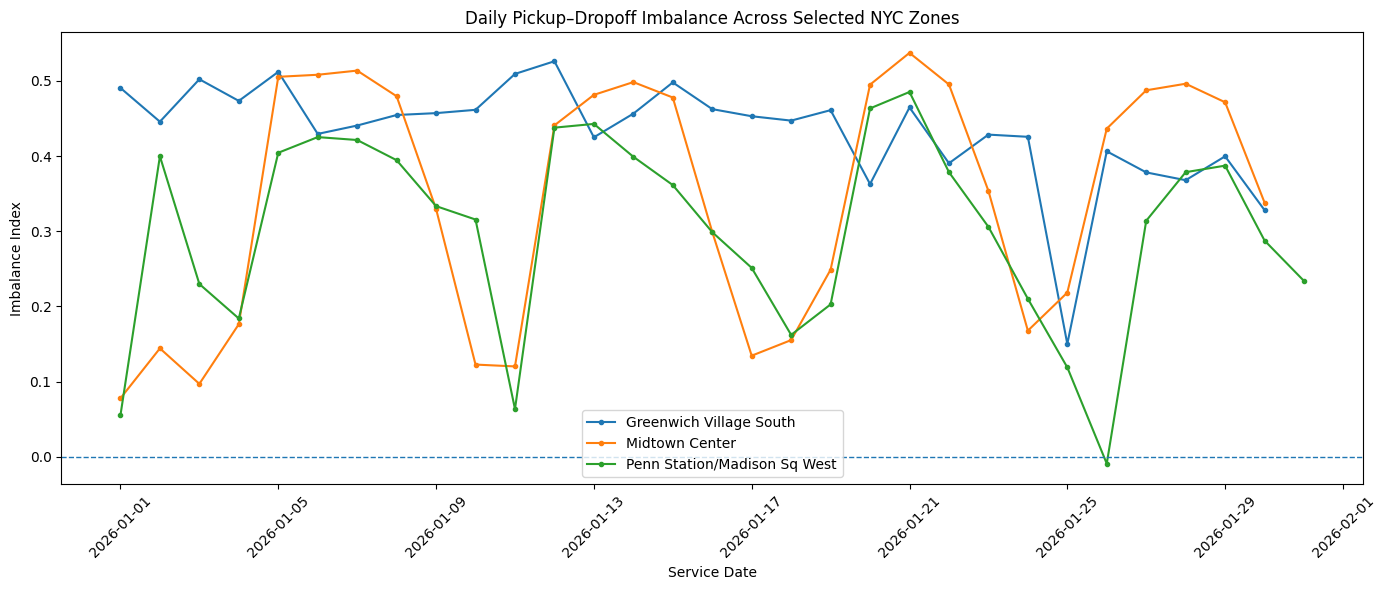

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for zone in daily_results["zone_name"].unique():
    temp = daily_results[daily_results["zone_name"] == zone]

    plt.plot(
        temp["service_date"],
        temp["daily_imbalance"],
        marker="o",
        markersize=3,
        label=zone
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Daily Pickup–Dropoff Imbalance Across Selected NYC Zones")
plt.xlabel("Service Date")
plt.ylabel("Imbalance Index")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

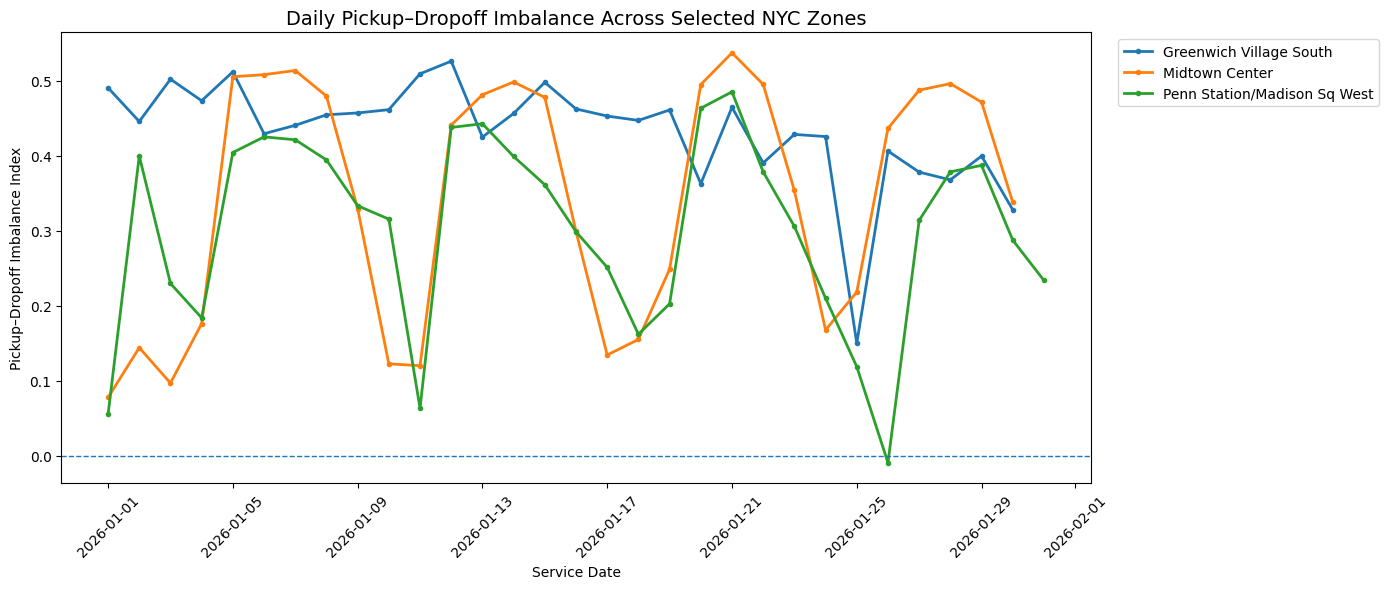

In [17]:
plt.figure(figsize=(14, 6))

for zone in daily_results["zone_name"].unique():
    temp = daily_results[
        daily_results["zone_name"] == zone
    ]

    plt.plot(
        temp["service_date"],
        temp["daily_imbalance"],
        marker="o",
        markersize=3,
        linewidth=2,
        label=zone
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Daily Pickup–Dropoff Imbalance Across Selected NYC Zones",
    fontsize=14
)

plt.xlabel("Service Date")
plt.ylabel("Pickup–Dropoff Imbalance Index")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
con.register("daily_results_view", daily_results)

In [19]:
query = """
WITH labeled_days AS (
    SELECT
        zone_name,
        service_date,
        pickups,
        dropoffs,
        daily_imbalance,

        CASE
            -- For the late-night nightlife window:
            -- Friday and Saturday nights are treated as weekend nights
            WHEN zone_name = 'Greenwich Village South'
                 AND EXTRACT(DOW FROM service_date) IN (5, 6)
            THEN 'Weekend'

            WHEN zone_name = 'Greenwich Village South'
            THEN 'Weekday'

            -- For Midtown and Penn Station:
            -- Saturday and Sunday are conventional weekends
            WHEN EXTRACT(DOW FROM service_date) IN (0, 6)
            THEN 'Weekend'

            ELSE 'Weekday'
        END AS day_type

    FROM daily_results_view
)

SELECT
    zone_name,
    day_type,

    COUNT(*) AS days,

    ROUND(AVG(daily_imbalance), 3)
        AS avg_imbalance,

    ROUND(MEDIAN(daily_imbalance), 3)
        AS median_imbalance,

    ROUND(AVG(pickups), 1)
        AS avg_daily_pickups,

    ROUND(AVG(dropoffs), 1)
        AS avg_daily_dropoffs,

    SUM(
        CASE WHEN daily_imbalance > 0
        THEN 1 ELSE 0 END
    ) AS pickup_heavy_days,

    ROUND(
        SUM(
            CASE WHEN daily_imbalance > 0
            THEN 1 ELSE 0 END
        ) * 100.0 / COUNT(*),
        1
    ) AS pickup_heavy_day_pct

FROM labeled_days

GROUP BY
    zone_name,
    day_type

ORDER BY
    zone_name,
    day_type;
"""

weekday_weekend = con.execute(query).df()

weekday_weekend

,zone_name,day_type,days,avg_imbalance,median_imbalance,avg_daily_pickups,avg_daily_dropoffs,pickup_heavy_days,pickup_heavy_day_pct
0,Greenwich Village South,Weekday,21,0.431,0.447,363.7,142.3,21.0,100.0
1,Greenwich Village South,Weekend,9,0.440,0.453,1488.3,584.1,9.0,100.0
2,Midtown Center,Weekday,22,0.414,0.479,2684.4,1053.0,22.0,100.0
3,Midtown Center,Weekend,8,0.149,0.145,1216.3,922.0,8.0,100.0
4,Penn Station/Madison Sq West,Weekday,22,0.344,0.383,1377.0,641.4,21.0,95.5
5,Penn Station/Madison Sq West,Weekend,9,0.196,0.210,1068.7,705.0,9.0,100.0


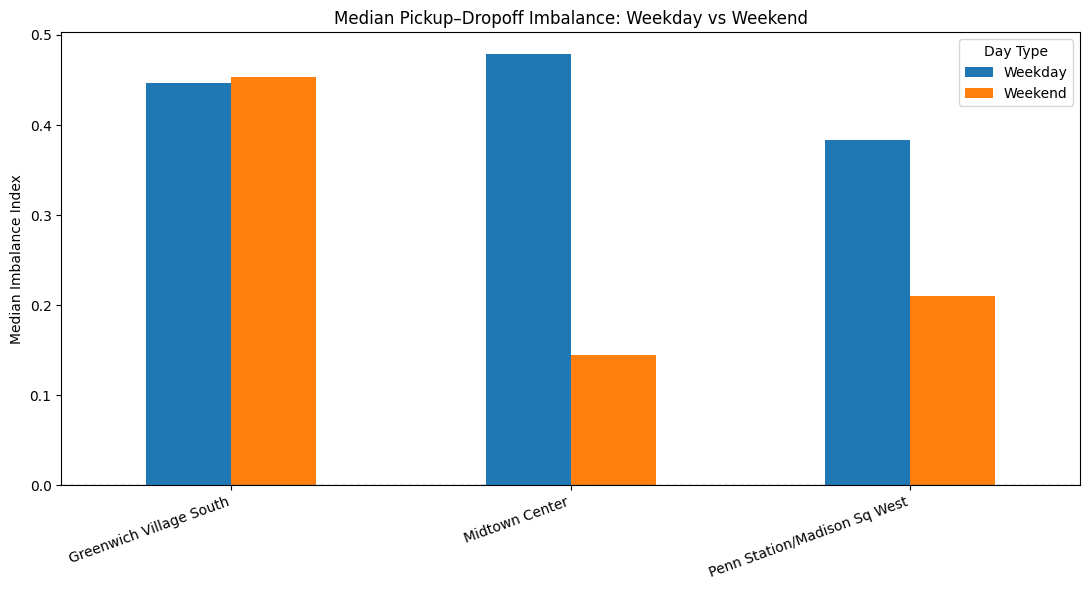

In [20]:
import matplotlib.pyplot as plt
import numpy as np

pivot = weekday_weekend.pivot(
    index="zone_name",
    columns="day_type",
    values="median_imbalance"
)

pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(
    "Median Pickup–Dropoff Imbalance: Weekday vs Weekend"
)

plt.xlabel("")
plt.ylabel("Median Imbalance Index")

plt.xticks(rotation=20, ha="right")

plt.legend(title="Day Type")

plt.tight_layout()

plt.show()

In [21]:
tableau_query = """
WITH pickups AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups
    FROM final_trips t
    JOIN zone_lookup z
        ON t.PULocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
      AND z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
    GROUP BY z.Borough, z.Zone, hour
),

dropoffs AS (
    SELECT
        z.Borough,
        z.Zone,
        EXTRACT(HOUR FROM t.tpep_dropoff_datetime) AS hour,
        COUNT(*) AS dropoffs
    FROM final_trips t
    JOIN zone_lookup z
        ON t.DOLocationID = z.LocationID
    WHERE z.Zone IS NOT NULL
      AND z.Zone NOT IN ('JFK Airport', 'LaGuardia Airport')
    GROUP BY z.Borough, z.Zone, hour
),

zone_totals AS (
    SELECT
        Borough,
        Zone,
        SUM(pickups) AS zone_total_pickups
    FROM pickups
    GROUP BY Borough, Zone
),

city_hourly AS (
    SELECT
        hour,
        SUM(pickups) AS city_hour_pickups
    FROM pickups
    GROUP BY hour
),

city_total AS (
    SELECT SUM(pickups) AS city_total_pickups
    FROM pickups
),

combined AS (
    SELECT
        p.Borough,
        p.Zone,
        p.hour,
        p.pickups,
        COALESCE(d.dropoffs, 0) AS dropoffs,
        zt.zone_total_pickups,
        ch.city_hour_pickups,
        ct.city_total_pickups
    FROM pickups p

    LEFT JOIN dropoffs d
        ON p.Borough = d.Borough
        AND p.Zone = d.Zone
        AND p.hour = d.hour

    JOIN zone_totals zt
        ON p.Borough = zt.Borough
        AND p.Zone = zt.Zone

    JOIN city_hourly ch
        ON p.hour = ch.hour

    CROSS JOIN city_total ct
)

SELECT
    Borough,
    Zone,
    hour,
    pickups,
    dropoffs,

    pickups + dropoffs AS total_activity,

    ROUND(
        (pickups - dropoffs) * 1.0
        / NULLIF(pickups + dropoffs, 0),
        4
    ) AS imbalance_index,

    ROUND(
        (pickups * 1.0 / zone_total_pickups)
        /
        (city_hour_pickups * 1.0 / city_total_pickups),
        4
    ) AS over_index

FROM combined

ORDER BY Borough, Zone, hour;
"""

tableau_data = con.execute(tableau_query).df()

tableau_data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,Borough,Zone,hour,pickups,dropoffs,total_activity,imbalance_index,over_index
0,Bronx,Allerton/Pelham Gardens,0,5,37,42,-0.7619,0.3541
1,Bronx,Allerton/Pelham Gardens,1,3,20,23,-0.7391,0.2939
2,Bronx,Allerton/Pelham Gardens,2,3,20,23,-0.7391,0.4149
3,Bronx,Allerton/Pelham Gardens,3,9,15,24,-0.2500,1.7362
4,Bronx,Allerton/Pelham Gardens,4,16,19,35,-0.0857,4.1675


In [22]:
tableau_data.to_csv(
    "/content/nyc_zone_hour_metrics.csv",
    index=False
)

daily_results.to_csv(
    "/content/nyc_daily_robustness.csv",
    index=False
)

print("Files exported.")

Files exported.
